In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

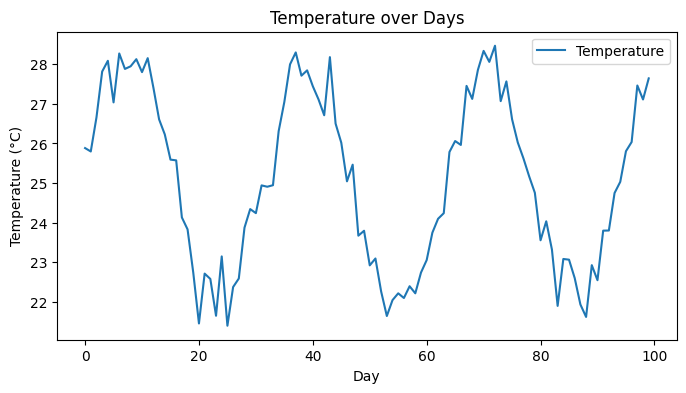

In [8]:
np.random.seed(0)
days = np.arange(0, 100)
temperature = 25 + 3 * np.sin(days * 0.2) + np.random.normal(0, 0.5, 100)  # some pattern + noise

plt.figure(figsize=(8,4))
plt.plot(days, temperature, label='Temperature')
plt.title('Temperature over Days')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [9]:
# ------------------------------
# Step 2: Prepare the data
# ------------------------------
data = temperature.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Function to create sequences
def create_sequences(dataset, time_steps=5):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i + time_steps), 0])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 5
X, y = create_sequences(data_scaled, time_steps)

# Reshape input to [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))


In [10]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(time_steps, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

c:\Users\shaid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
history = model.fit(X, y, epochs=100, verbose=0)

In [12]:
predicted = model.predict(X)
predicted_inv = scaler.inverse_transform(predicted)
actual_inv = scaler.inverse_transform(y.reshape(-1, 1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


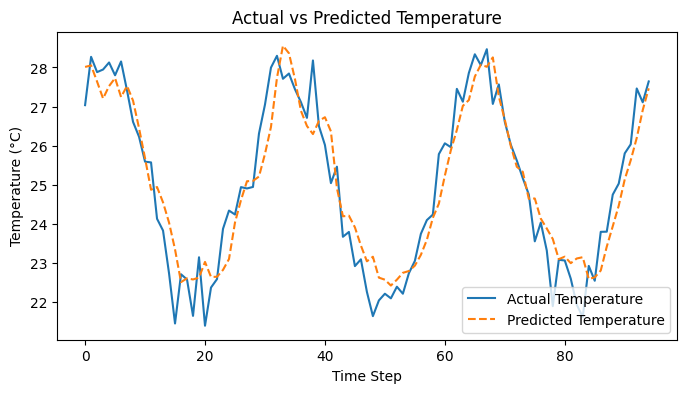

In [13]:
plt.figure(figsize=(8,4))
plt.plot(actual_inv, label='Actual Temperature')
plt.plot(predicted_inv, label='Predicted Temperature', linestyle='--')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [14]:
print("Example prediction:")
for i in range(5):
    print(f"Actual: {actual_inv[i][0]:.2f}°C, Predicted: {predicted_inv[i][0]:.2f}°C")

Example prediction:
Actual: 27.04°C, Predicted: 28.01°C
Actual: 28.27°C, Predicted: 28.05°C
Actual: 27.88°C, Predicted: 27.64°C
Actual: 27.95°C, Predicted: 27.21°C
Actual: 28.13°C, Predicted: 27.52°C
